# __Visualizacion de Datos__

## Boxplot

### Definicion

> Percentil: es un valor que divide el conjunto de datos en dos partes. Percentil 50 indica que debajo se encuentra el 50% de los datos y por encima el otro 50%.

> Percentil 50 tambien se conoce como la mediana.

> Percentiles 25, 50 y 75 se conocen como cuantiles. Representan la caja del Boxplot

> La caja del boxplot se conoce como Rango Intercuantilico IQR.

> El IQR contiene el 50% de los datos.

> Los bigotes se forman sumando 1.5 veces el IQR al Q3  y restando la misma proporcion a Q1.

> Datos fuera de los bigotes se conocen como Outliers.


<img src="https://www.researchgate.net/publication/340996565/figure/fig3/AS:962186885210119@1606414638167/Box-plot-and-probability-density-function-of-a-normal-distribution.png" alt="boxplot" width="600"/>

### Ejemplo con codigo

Vamos a trabajar sobre los datos de la poblacion de EE.UU

In [14]:
# librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
direct_link = 'https://drive.google.com/uc?export=download&id=1zjJIKIT2kcIW9HwmI50nopxLwMwqC1KB'
df = pd.read_csv(direct_link)
df

,age,sex,education,heigh,income
0,39,Male,Bachelors,70.005853,<=50K
1,50,Male,Bachelors,71.998300,<=50K
2,38,Male,HS-grad,77.583585,<=50K
3,53,Male,11th,75.583042,<=50K
4,28,Female,Bachelors,62.938658,<=50K
...,...,...,...,...,...
32556,27,Female,Assoc-acdm,63.180932,<=50K
32557,40,Male,HS-grad,69.362275,>50K
32558,58,Female,HS-grad,64.346106,<=50K
32559,22,Male,HS-grad,68.709801,<=50K


__1. Obtener el boxplot de heigh basado en el sexo__

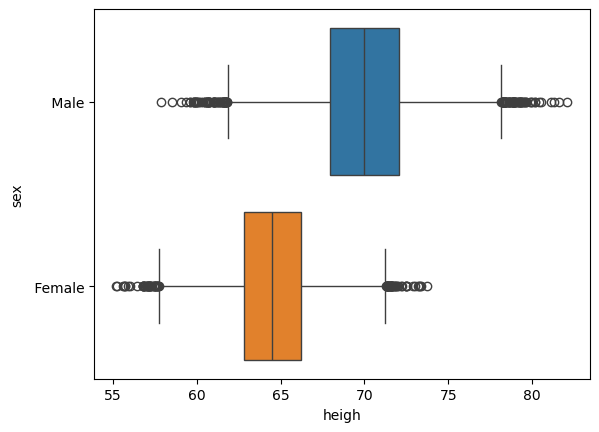

In [4]:
sns.boxplot(x=df.heigh, y=df.sex, hue=df.sex);

__2. Obtener la distribucion de age__

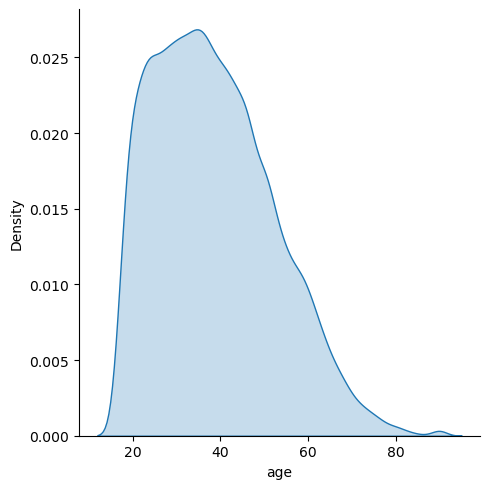

In [5]:
sns.displot(df.age, kind='kde', fill=True);

__3. Obtener el boxplot de age__

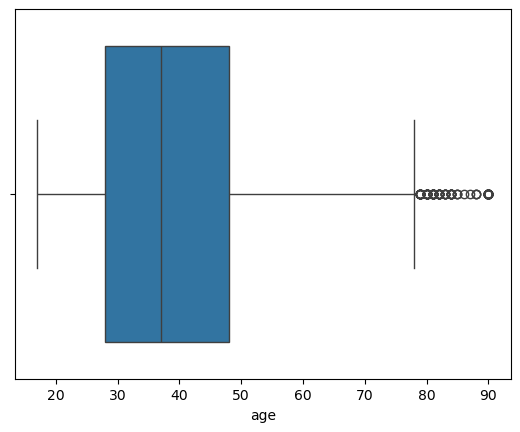

In [6]:
sns.boxplot(x=df.age);

__4. Calcular los cuantiles__

In [7]:
data = df.age

# calcular cuantiles 25 y 75
q25, q75 = np.percentile(data, 25), np.percentile(data, 75)

# calcular IQR
iqr = q75 - q25

# obtener Q75
cut_off = iqr * 1.5
upper = q75 + cut_off
upper

np.float64(78.0)

In [8]:
# obtener Q25
lower = q25 - cut_off
lower

np.float64(-2.0)

__5. Identificar Outliers__

In [9]:
df[df.age > upper]

,age,sex,education,heigh,income
74,79,Male,Some-college,72.517188,<=50K
222,90,Male,HS-grad,68.573528,<=50K
430,80,Male,HS-grad,68.338329,<=50K
918,81,Male,HS-grad,66.747391,<=50K
1040,90,Female,HS-grad,65.709909,<=50K
...,...,...,...,...,...
32277,90,Female,HS-grad,66.838245,<=50K
32367,90,Male,7th-8th,68.164556,<=50K
32459,85,Male,Bachelors,72.380856,<=50K
32494,82,Male,HS-grad,72.895330,<=50K


In [10]:
# Porcentaje de outliers
143 / df.shape[0] * 100

0.4391757009919842

> Hay 0.4% de valores atipicos en los datos

__6. Obtener el boxplot de age en funcion del sexo__

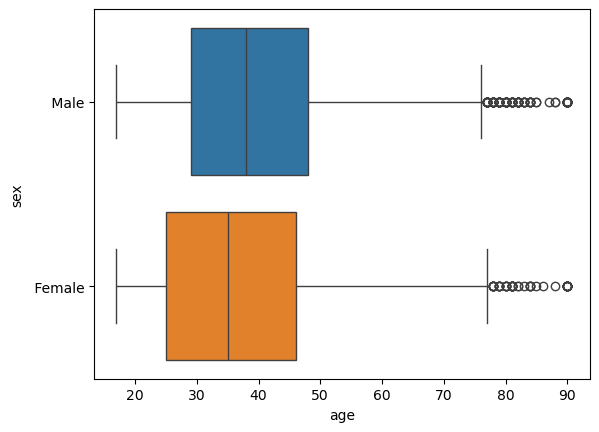

In [12]:
sns.boxplot(x=df.age, y=df.sex, hue=df.sex);

## Stratification

Consiste en tomar una variable y visualizarla a traves de otras variables o categorias. Ejemplo, al visualizar la altura de la poblacion, la estratificamos a traves del sexo.

__1. Diagrama de barra de los ingresos estratificado por el sexo__

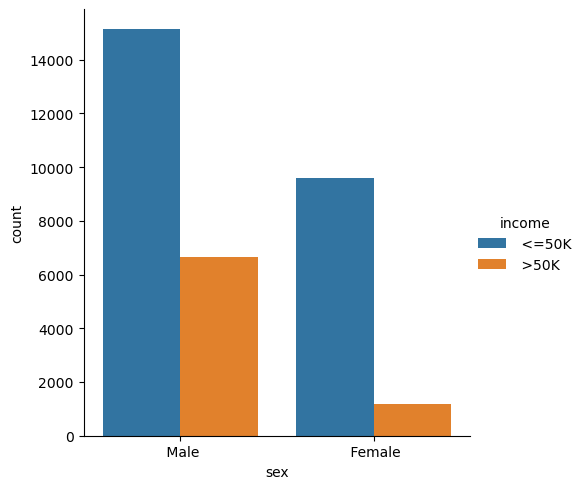

In [13]:
sns.catplot(data=df, x='sex', kind='count', hue='income');

__2. Diagrama de barra de los ingresos estratificado por educacion__

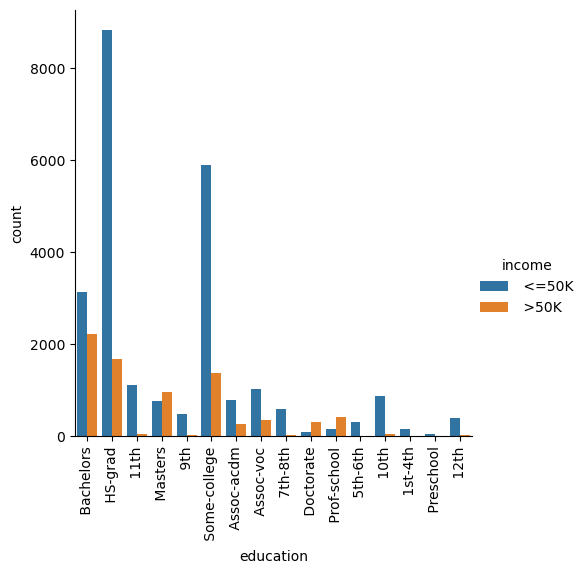

In [15]:
sns.catplot(data=df, x='education', kind='count', hue='income');
plt.xticks(rotation=90);

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1h-ARVXYpo3LzCLJEZqtqnEbHF31DxAuR')
df

,country,year,infant_mortality,life_expectancy,fertility,population,gdp,continent,region
0,Albania,1960,115.40,62.87,6.19,1636054.0,NaN,Europe,Southern Europe
1,Algeria,1960,148.20,47.50,7.65,11124892.0,1.382815e+10,Africa,Northern Africa
2,Angola,1960,208.00,35.98,7.32,5270844.0,NaN,Africa,Middle Africa
3,Antigua and Barbuda,1960,NaN,62.97,4.43,54681.0,NaN,Americas,Caribbean
4,Argentina,1960,59.87,65.39,3.11,20619075.0,1.083223e+11,Americas,South America
...,...,...,...,...,...,...,...,...,...
10540,West Bank and Gaza,2016,NaN,74.70,NaN,NaN,NaN,Asia,Western Asia
10541,Vietnam,2016,NaN,75.60,NaN,NaN,NaN,Asia,South-Eastern Asia
10542,Yemen,2016,NaN,64.92,NaN,NaN,NaN,Asia,Western Asia
10543,Zambia,2016,NaN,57.10,NaN,NaN,NaN,Africa,Eastern Africa


# Introducción al caso de uso

1. Sri Lanka o Turquía
2. Polonia o Corea del Sur
3. Malasia o Rusia
4. Pakistan o Vietnam
5. Tailandia o Sur África



In [ ]:
pairs = [('Sri Lanka', 'Turkey'),
        ('Poland', 'South Korea'),
        ('Malaysia', 'Russia'),
        ('Pakistan', 'Vietnam'),
        ('Thailand', 'South Africa')]
for i,j in pairs:
    display(df[['country', 'infant_mortality']][(df.year == 2015) & (df.country.isin([i,j]))].reset_index(drop=True))

,country,infant_mortality
0,Sri Lanka,8.4
1,Turkey,11.6


,country,infant_mortality
0,South Korea,2.9
1,Poland,4.5


,country,infant_mortality
0,Malaysia,6.0
1,Russia,8.2


,country,infant_mortality
0,Pakistan,65.8
1,Vietnam,17.3


,country,infant_mortality
0,South Africa,33.6
1,Thailand,10.5


# Scatterplots

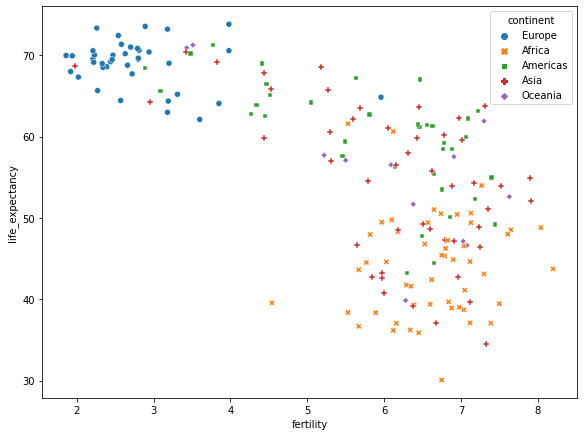

In [ ]:
h, w = np.array([6.4, 4.8]) * 1.5
fig, ax = plt.subplots(figsize=(h, w))
sns.scatterplot(data=df[df.year == 1962], x='fertility', y='life_expectancy', hue='continent', style='continent');

# Faceting

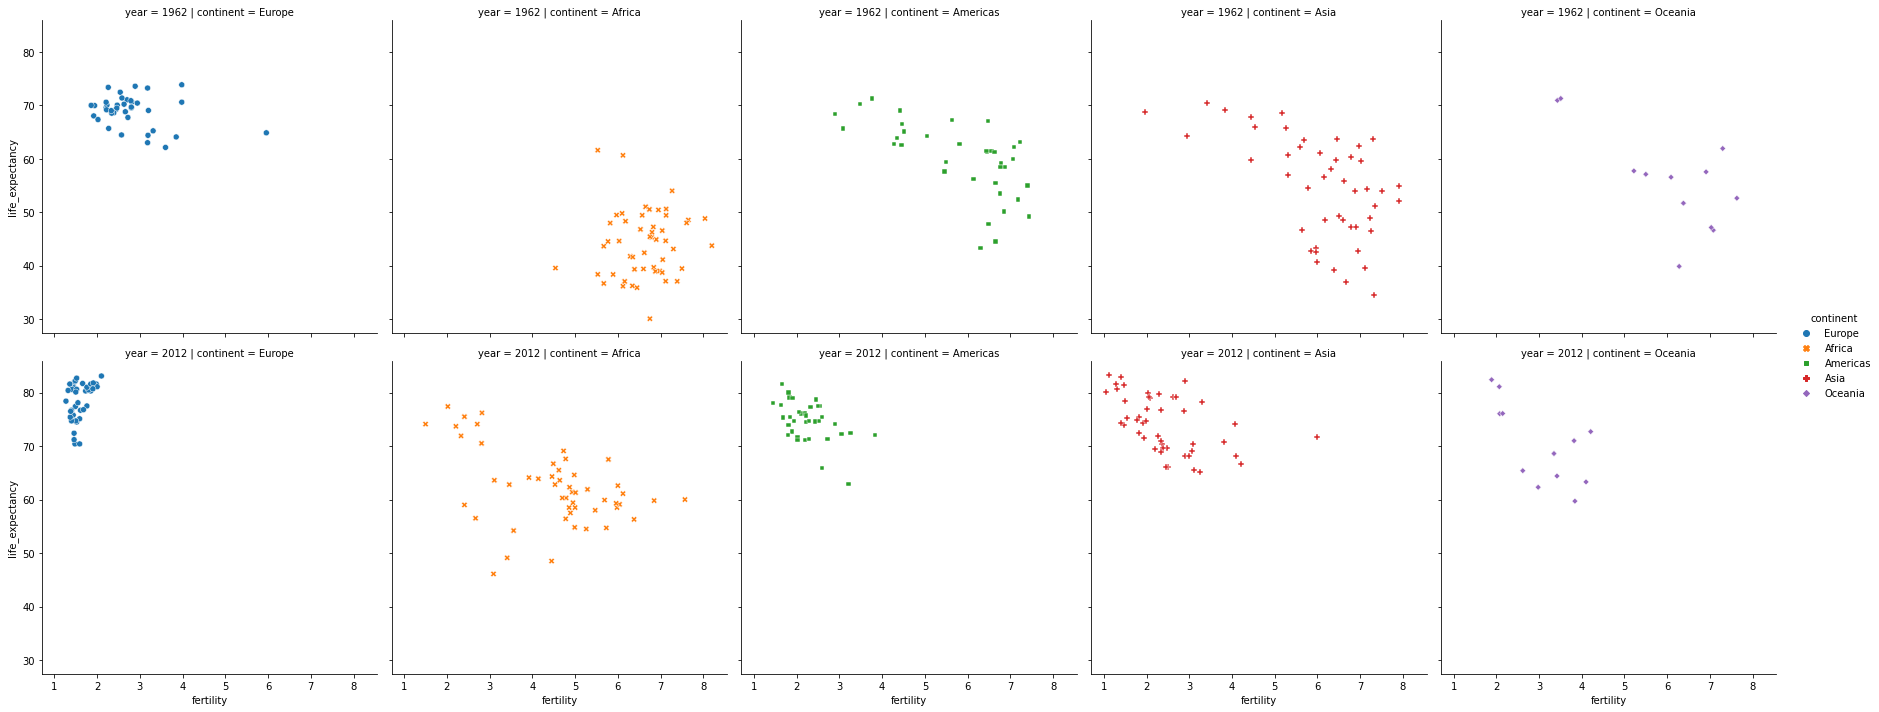

In [ ]:
sns.relplot(data=df[df.year.isin([1962, 2012])], x='fertility', y='life_expectancy', \
            hue='continent', style='continent', col='continent', row='year');

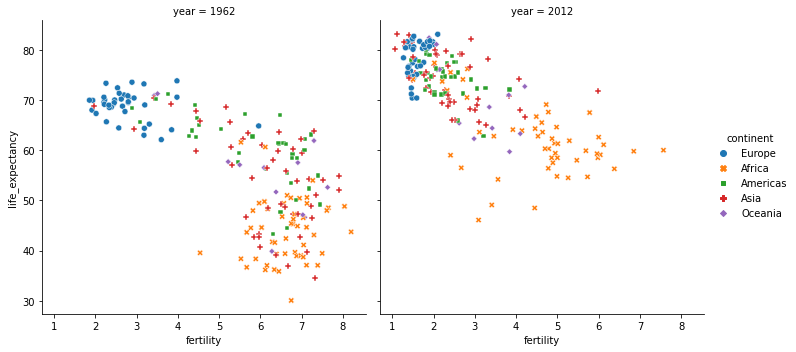

In [ ]:
sns.relplot(data=df[df.year.isin([1962, 2012])], x='fertility', y='life_expectancy', hue='continent', style='continent', col='year');

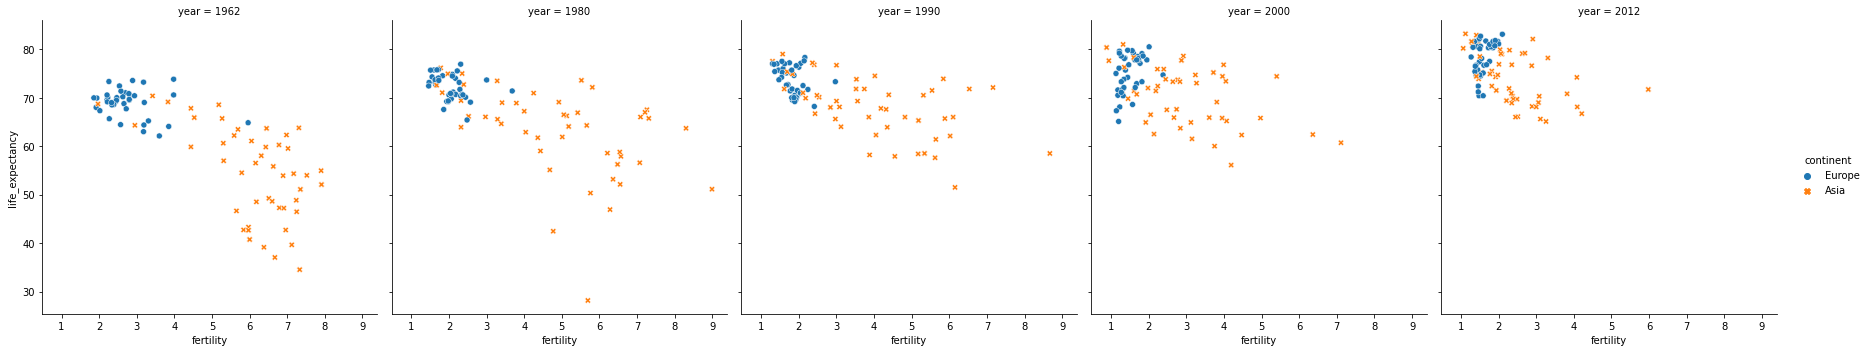

In [ ]:
sns.relplot(data=df[df.continent.isin(['Europe', 'Asia']) & df.year.isin([1962, 1980, 1990, 2000, 2012])], x='fertility', y='life_expectancy', hue='continent', style='continent', col='year');

# Scales

# Time series

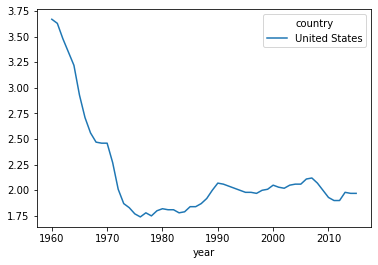

In [ ]:
df[df.country.isin(['United States'])].pivot(index='year', columns='country', values='fertility').plot();

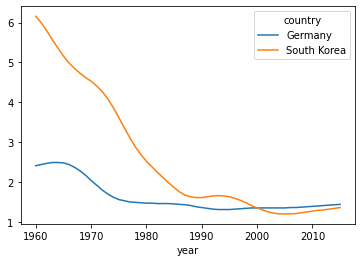

In [ ]:
df[df.country.isin(['South Korea', 'Germany'])].pivot(index='year', columns='country', values='fertility').plot();

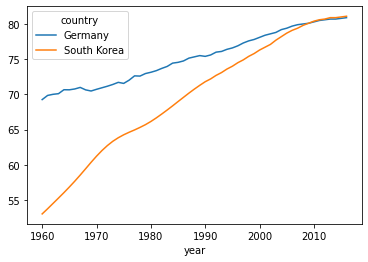

In [ ]:
df[df.country.isin(['South Korea', 'Germany'])].pivot(index='year', columns='country', values='life_expectancy').plot();